# 02 Exploratory Analysis

## Goal
Explore the integrated patient-level dataset to understand demographics, utilization, clinical burden, and potential care gap patterns in geriatric patients.

1: Load the processed patient-level dataset

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path

DATA_PATH = Path("../data/processed/patient_level_analytics.csv")
df = pd.read_csv(DATA_PATH)

df.head()
df.shape

(31, 42)

In [4]:
DATA_DIR = Path("../data/raw")

patients = pd.read_csv(DATA_DIR / "patients.csv")
encounters = pd.read_csv(DATA_DIR / "encounters.csv")
conditions = pd.read_csv(DATA_DIR / "conditions.csv")
medications = pd.read_csv(DATA_DIR / "medications.csv")
claims = pd.read_csv(DATA_DIR / "claims.csv")
observations = pd.read_csv(DATA_DIR / "observations.csv")
providers = pd.read_csv(DATA_DIR / "providers.csv")

2: Basic data check

In [5]:
df.info()
df.isna().sum().sort_values(ascending=False).head(20)
df.describe(include="all")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31 entries, 0 to 30
Data columns (total 42 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   patient_id_pat           31 non-null     object 
 1   birthdate                31 non-null     object 
 2   deathdate                13 non-null     object 
 3   ssn                      31 non-null     object 
 4   drivers                  30 non-null     object 
 5   passport                 30 non-null     object 
 6   prefix                   30 non-null     object 
 7   first                    31 non-null     object 
 8   middle                   25 non-null     object 
 9   last                     31 non-null     object 
 10  suffix                   0 non-null      float64
 11  maiden                   5 non-null      object 
 12  marital                  30 non-null     object 
 13  race                     31 non-null     object 
 14  ethnicity                31 

,patient_id_pat,birthdate,deathdate,ssn,drivers,passport,prefix,first,middle,last,...,total_conditions,unique_conditions,total_medications,unique_medications,total_claims,total_observations,age_group,high_utilization_flag,high_comorbidity_flag,potential_care_gap_flag
count,31,31,13,31,30,30,30,31,25,31,...,31.000000,31.000000,31.000000,31.000000,31.000000,31.000000,31,31.000000,31.000000,31.0
unique,31,18,13,31,30,30,2,31,25,31,...,NaN,NaN,NaN,NaN,NaN,NaN,3,NaN,NaN,NaN
top,cd1812c1-21c3-e70e-c635-fec819c488aa,1918-03-06,1989-06-12,999-71-5044,S99951898,X62372693X,Mr.,Marquetta382,Maryetta775,Cole117,...,NaN,NaN,NaN,NaN,NaN,NaN,65-74,NaN,NaN,NaN
freq,1,7,1,1,1,1,25,1,1,1,...,NaN,NaN,NaN,NaN,NaN,NaN,14,NaN,NaN,NaN
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,60.193548,26.903226,142.193548,11.290323,229.225806,1817.612903,NaN,0.258065,0.258065,0.0
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,55.899564,9.104412,242.182358,6.497146,340.682130,2506.409446,NaN,0.444803,0.444803,0.0
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,8.000000,5.000000,4.000000,3.000000,23.000000,137.000000,NaN,0.000000,0.000000,0.0
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,32.500000,22.000000,18.500000,5.000000,57.500000,565.000000,NaN,0.000000,0.000000,0.0
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,40.000000,26.000000,48.000000,10.000000,93.000000,754.000000,NaN,0.000000,0.000000,0.0
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,48.000000,30.500000,121.500000,16.000000,233.500000,1819.500000,NaN,0.500000,0.500000,0.0


3: Write down the questions this notebook will answer
## Questions explored

1. What are the demographic characteristics of the geriatric population?
2. How are utilization patterns distributed across age groups and patient subgroups?
3. How does clinical burden vary across the population?
4. Which subgroups show signals of potential care gaps?

4: Population overview

In [6]:
#summary metrics
print("Total patients:", len(df))
print("Average age:", round(df["age"].mean(), 1))
print("Median age:", round(df["age"].median(), 1))

Total patients: 31
Average age: 85.9
Median age: 77.2


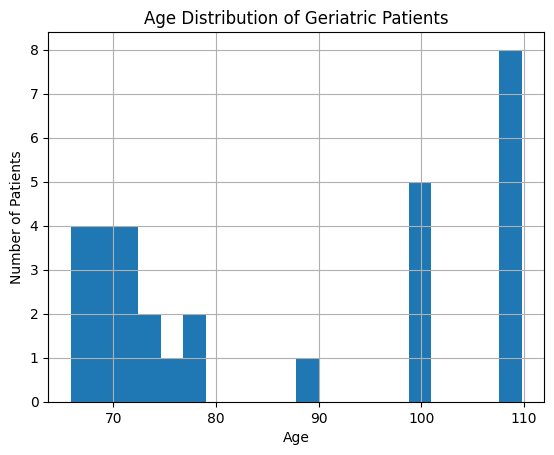

In [7]:
#age distribution
df["age"].hist(bins=20)
plt.xlabel("Age")
plt.ylabel("Number of Patients")
plt.title("Age Distribution of Geriatric Patients")
plt.show()

In [8]:
#age group counts
df["age_group"].value_counts(dropna=False).sort_index()

age_group
65-74    14
75-84     3
85+      14
Name: count, dtype: int64

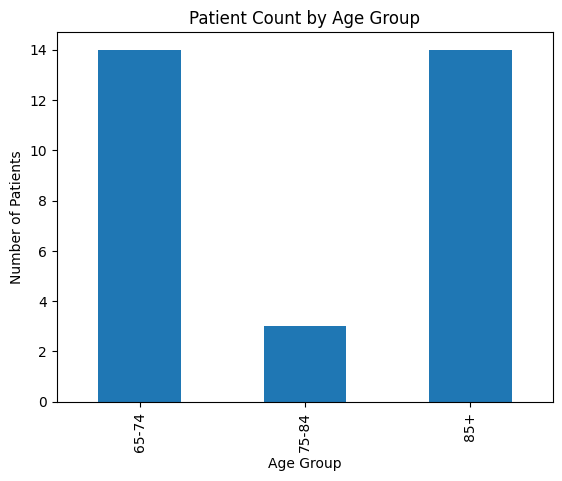

In [9]:
#display chart
df["age_group"].value_counts(dropna=False).sort_index().plot(kind="bar")
plt.xlabel("Age Group")
plt.ylabel("Number of Patients")
plt.title("Patient Count by Age Group")
plt.show()

In [10]:
#gender distribution
df["gender"].value_counts(dropna=False)

gender
M    26
F     5
Name: count, dtype: int64

In [11]:
#race/ethnicity
df["race"].value_counts(dropna=False).head(10)
df["ethnicity"].value_counts(dropna=False).head(10)

ethnicity
nonhispanic    26
hispanic        5
Name: count, dtype: int64

5: Utilization analysis: looking at

total encounters
hospitalization count
claims count if you have it
utilization by age group
utilization by demographic subgroups

In [12]:
#summary
df["total_encounters"].describe()
df["hospitalization_count"].describe()

count    31.000000
mean      2.516129
std       5.875775
min       0.000000
25%       0.000000
50%       1.000000
75%       2.500000
max      32.000000
Name: hospitalization_count, dtype: float64

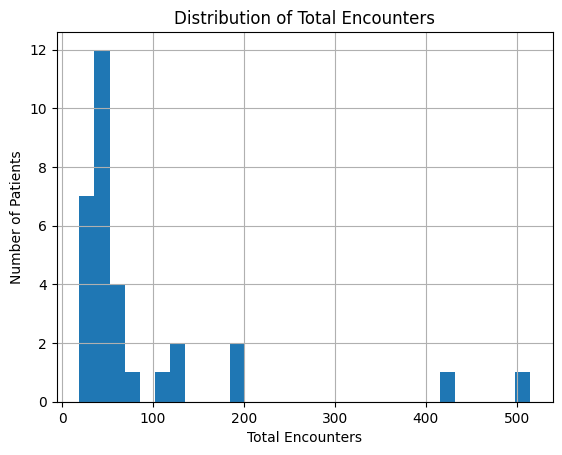

In [13]:
#Distribution of total encounters
df["total_encounters"].hist(bins=30)
plt.xlabel("Total Encounters")
plt.ylabel("Number of Patients")
plt.title("Distribution of Total Encounters")
plt.show()

In [14]:
#encounters by age group
df.groupby("age_group")["total_encounters"].mean()

age_group
65-74     59.000000
75-84     91.333333
85+      114.142857
Name: total_encounters, dtype: float64

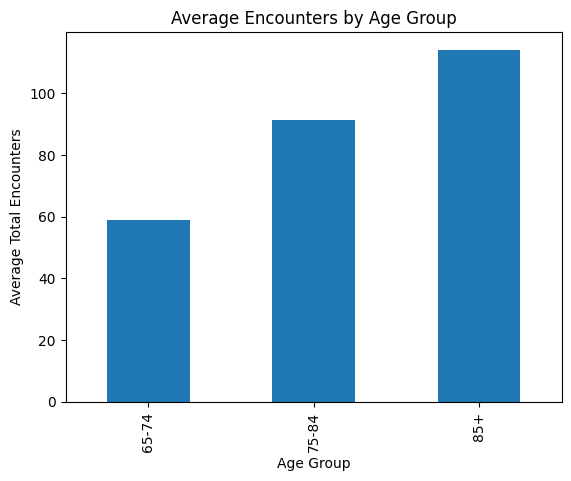

In [15]:
#display chart
df.groupby("age_group")["total_encounters"].mean().plot(kind="bar")
plt.xlabel("Age Group")
plt.ylabel("Average Total Encounters")
plt.title("Average Encounters by Age Group")
plt.show()

In [16]:
#Hospitalization rate by age group
df.groupby("age_group")["any_hospitalization_flag"].mean()

KeyError: 'Column not found: any_hospitalization_flag'

In [ ]:
df.columns.tolist()

['patient_id_pat',
 'birthdate',
 'deathdate',
 'ssn',
 'drivers',
 'passport',
 'prefix',
 'first',
 'middle',
 'last',
 'suffix',
 'maiden',
 'marital',
 'race',
 'ethnicity',
 'gender',
 'birthplace',
 'address',
 'city',
 'state',
 'county',
 'fips',
 'zip',
 'lat',
 'lon',
 'healthcare_expenses',
 'healthcare_coverage',
 'income',
 'age',
 'id',
 'total_encounters',
 'hospitalization_count',
 'total_conditions',
 'unique_conditions',
 'total_medications',
 'unique_medications',
 'total_claims',
 'total_observations',
 'age_group',
 'high_utilization_flag',
 'high_comorbidity_flag',
 'potential_care_gap_flag']

In [17]:
encounters.columns.tolist()

['Id',
 'START',
 'STOP',
 'PATIENT',
 'ORGANIZATION',
 'PROVIDER',
 'PAYER',
 'ENCOUNTERCLASS',
 'CODE',
 'DESCRIPTION',
 'BASE_ENCOUNTER_COST',
 'TOTAL_CLAIM_COST',
 'PAYER_COVERAGE',
 'REASONCODE',
 'REASONDESCRIPTION']

In [18]:
patients.columns.tolist()


['Id',
 'BIRTHDATE',
 'DEATHDATE',
 'SSN',
 'DRIVERS',
 'PASSPORT',
 'PREFIX',
 'FIRST',
 'MIDDLE',
 'LAST',
 'SUFFIX',
 'MAIDEN',
 'MARITAL',
 'RACE',
 'ETHNICITY',
 'GENDER',
 'BIRTHPLACE',
 'ADDRESS',
 'CITY',
 'STATE',
 'COUNTY',
 'FIPS',
 'ZIP',
 'LAT',
 'LON',
 'HEALTHCARE_EXPENSES',
 'HEALTHCARE_COVERAGE',
 'INCOME']

In [19]:
df.columns.tolist()


['patient_id_pat',
 'birthdate',
 'deathdate',
 'ssn',
 'drivers',
 'passport',
 'prefix',
 'first',
 'middle',
 'last',
 'suffix',
 'maiden',
 'marital',
 'race',
 'ethnicity',
 'gender',
 'birthplace',
 'address',
 'city',
 'state',
 'county',
 'fips',
 'zip',
 'lat',
 'lon',
 'healthcare_expenses',
 'healthcare_coverage',
 'income',
 'age',
 'id',
 'total_encounters',
 'hospitalization_count',
 'total_conditions',
 'unique_conditions',
 'total_medications',
 'unique_medications',
 'total_claims',
 'total_observations',
 'age_group',
 'high_utilization_flag',
 'high_comorbidity_flag',
 'potential_care_gap_flag']

In [20]:
#df is patient-level only:1 — Create hospitalization flag in encounters
encounters["hospitalization_flag"] = (encounters["ENCOUNTERCLASS"] == "inpatient").astype(int)


In [21]:
#df is patient-level only:2 — Aggregate to patient level
hospitalization_summary = (
    encounters.groupby("PATIENT")["hospitalization_flag"]
    .sum()
    .reset_index()
    .rename(columns={"PATIENT": "patient_id_pat"})
)


In [22]:
#df is patient-level only:3 — Merge into df
df = df.merge(hospitalization_summary, on="patient_id_pat", how="left")
df["hospitalization_flag"] = df["hospitalization_flag"].fillna(0).astype(int)


In [23]:
#coming back to 5: Utlizzation analysis 
df.groupby("age_group")["hospitalization_flag"].mean()


age_group
65-74    1.000000
75-84    1.666667
85+      4.214286
Name: hospitalization_flag, dtype: float64

6: Clinical burden analysis

In [24]:
#summaries
df["unique_conditions"].describe()

count    31.000000
mean     26.903226
std       9.104412
min       5.000000
25%      22.000000
50%      26.000000
75%      30.500000
max      52.000000
Name: unique_conditions, dtype: float64

In [25]:
#summaries
df["unique_medications"].describe()

count    31.000000
mean     11.290323
std       6.497146
min       3.000000
25%       5.000000
50%      10.000000
75%      16.000000
max      29.000000
Name: unique_medications, dtype: float64

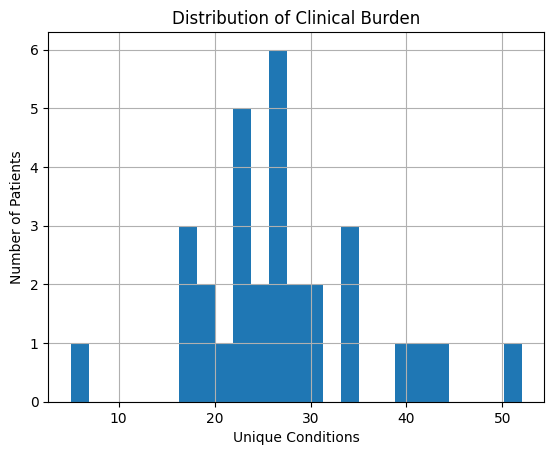

In [26]:
#Condition burden distribution
df["unique_conditions"].hist(bins=25)
plt.xlabel("Unique Conditions")
plt.ylabel("Number of Patients")
plt.title("Distribution of Clinical Burden")
plt.show()

In [27]:
#Burden by age group
df.groupby("age_group")["unique_conditions"].mean()

age_group
65-74    25.357143
75-84    28.000000
85+      28.214286
Name: unique_conditions, dtype: float64

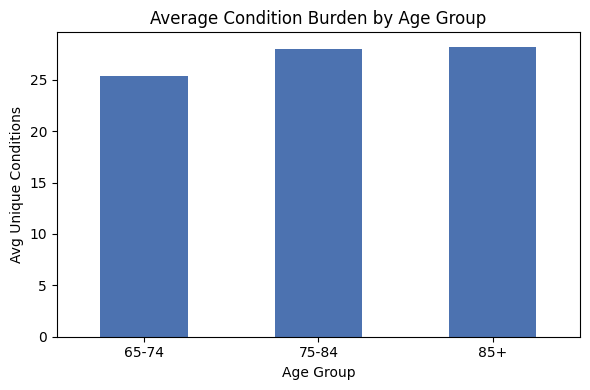

In [28]:
#plot burden by age
burden_by_age = df.groupby("age_group")["unique_conditions"].mean()

plt.figure(figsize=(6,4))
burden_by_age.plot(kind="bar", color="#4C72B0")
plt.ylabel("Avg Unique Conditions")
plt.xlabel("Age Group")
plt.title("Average Condition Burden by Age Group")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


In [29]:
#Medications by age group
df.groupby("age_group")["unique_medications"].mean()

age_group
65-74    10.071429
75-84    13.000000
85+      12.142857
Name: unique_medications, dtype: float64

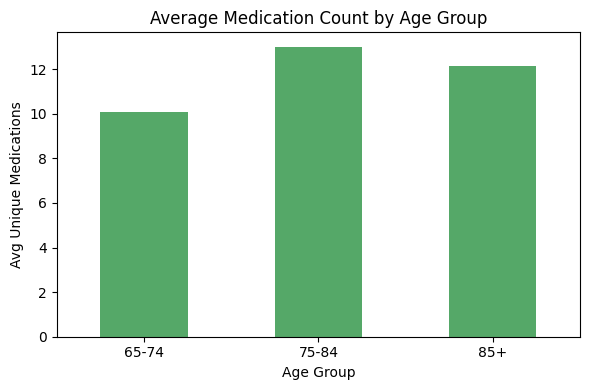

In [30]:
# plot medication by age group
meds_by_age = df.groupby("age_group")["unique_medications"].mean()

plt.figure(figsize=(6,4))
meds_by_age.plot(kind="bar", color="#55A868")
plt.ylabel("Avg Unique Medications")
plt.xlabel("Age Group")
plt.title("Average Medication Count by Age Group")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


7: Exploring care gap proxy for this dataset
since we created:
potential_care_gap_flag
high_utilization_flag
high_comorbidity_flag

Now is the time to explore them.

In [31]:
#Overall care gap rate
df["potential_care_gap_flag"].mean()

np.float64(0.0)

In [32]:
#Care gap by age group
df.groupby("age_group")["potential_care_gap_flag"].mean()

age_group
65-74    0.0
75-84    0.0
85+      0.0
Name: potential_care_gap_flag, dtype: float64

In [33]:
#Care gap by gender
df.groupby("gender")["potential_care_gap_flag"].mean()

gender
F    0.0
M    0.0
Name: potential_care_gap_flag, dtype: float64

In [34]:
df["unique_conditions"].quantile([0.5, 0.75, 0.9])
df["total_encounters"].quantile([0.5, 0.75, 0.9])


0.50     47.0
0.75     69.0
0.90    190.0
Name: total_encounters, dtype: float64

In [35]:
df["unique_conditions"].quantile([0.5, 0.75, 0.9])

0.50    26.0
0.75    30.5
0.90    39.0
Name: unique_conditions, dtype: float64

In [36]:
df["unique_conditions"].describe()



count    31.000000
mean     26.903226
std       9.104412
min       5.000000
25%      22.000000
50%      26.000000
75%      30.500000
max      52.000000
Name: unique_conditions, dtype: float64

In [37]:
df["unique_medications"].describe()


count    31.000000
mean     11.290323
std       6.497146
min       3.000000
25%       5.000000
50%      10.000000
75%      16.000000
max      29.000000
Name: unique_medications, dtype: float64

In [38]:
df["total_encounters"].describe()

count     31.000000
mean      87.032258
std      111.653776
min       19.000000
25%       36.500000
50%       47.000000
75%       69.000000
max      515.000000
Name: total_encounters, dtype: float64

In [39]:
#care gap by age group
df.groupby("age_group")["potential_care_gap_flag"].mean()

age_group
65-74    0.0
75-84    0.0
85+      0.0
Name: potential_care_gap_flag, dtype: float64

since everything is coming out as zero, i am defining clinical morbidity

In [42]:
# Define high comorbidity clinically, not statistically
df["high_comorbidity_flag"] = (df["unique_conditions"] >= 5).astype(int)

# Define low utilization relative to burden
df["low_utilization_flag"] = (df["total_encounters"] < 30).astype(int)

# Care gap proxy: high burden + low utilization
df["potential_care_gap_flag"] = (
    (df["high_comorbidity_flag"] == 1) &
    (df["low_utilization_flag"] == 1)
).astype(int)


In [43]:
df["potential_care_gap_flag"].mean()
df.groupby("age_group")["potential_care_gap_flag"].mean()
df.groupby("gender")["potential_care_gap_flag"].mean()


gender
F    0.000000
M    0.076923
Name: potential_care_gap_flag, dtype: float64

In [44]:
#Overall care gap rate
df["potential_care_gap_flag"].mean()

np.float64(0.06451612903225806)

In [45]:
#Care gap by age group
df.groupby("age_group")["potential_care_gap_flag"].mean()

age_group
65-74    0.071429
75-84    0.000000
85+      0.071429
Name: potential_care_gap_flag, dtype: float64

In [46]:
#Care gap by gender
df.groupby("gender")["potential_care_gap_flag"].mean()

gender
F    0.000000
M    0.076923
Name: potential_care_gap_flag, dtype: float64

In [47]:
#Care gap by race if appropriate
df.groupby("race")["potential_care_gap_flag"].mean().sort_values(ascending=False).head(10)

race
white    0.074074
black    0.000000
Name: potential_care_gap_flag, dtype: float64

8: Looking at relationships between burden and utilization (Analysis to answer following quetsions)

Questions:

do patients with more conditions use more care?
are there patients with high burden but unexpectedly low utilization?
does hospitalization rise with condition burden?

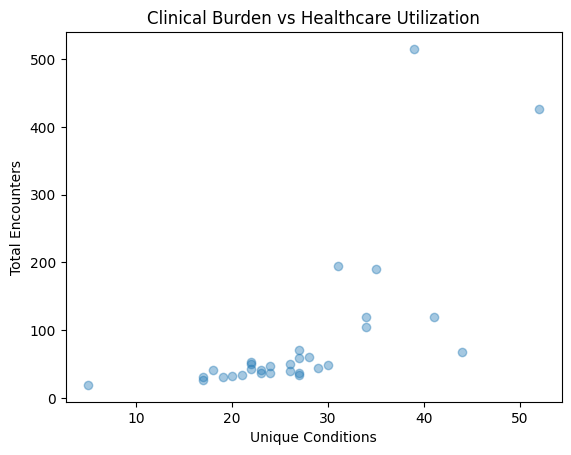

In [48]:
plt.scatter(df["unique_conditions"], df["total_encounters"], alpha=0.4)
plt.xlabel("Unique Conditions")
plt.ylabel("Total Encounters")
plt.title("Clinical Burden vs Healthcare Utilization")
plt.show()

In [49]:
#Cross-tab: creating burden/utilization quadrants.

condition_cutoff = df["unique_conditions"].median()
encounter_cutoff = df["total_encounters"].median()

df["burden_group"] = np.where(df["unique_conditions"] >= condition_cutoff, "High Burden", "Low Burden")
df["utilization_group"] = np.where(df["total_encounters"] >= encounter_cutoff, "High Utilization", "Low Utilization")

pd.crosstab(df["burden_group"], df["utilization_group"])

utilization_group,High Utilization,Low Utilization
burden_group,,
High Burden,13,4
Low Burden,3,11


This shows that:
High burden + low utilization looks lika a care-gap-like group
High burden + high utilization might be a high-need group

9: some insights: 
## Preliminary Insights

- Older age groups showed higher average encounter counts and hospitalization rates.
- Clinical burden, measured by number of unique conditions, increased across geriatric age bands.
- A subset of patients appears to have relatively high clinical burden but lower healthcare utilization, suggesting a potential care gap pattern worth exploring further.
- These early findings support the next steps of patient segmentation and risk modeling.

10: CReate and Save key figures

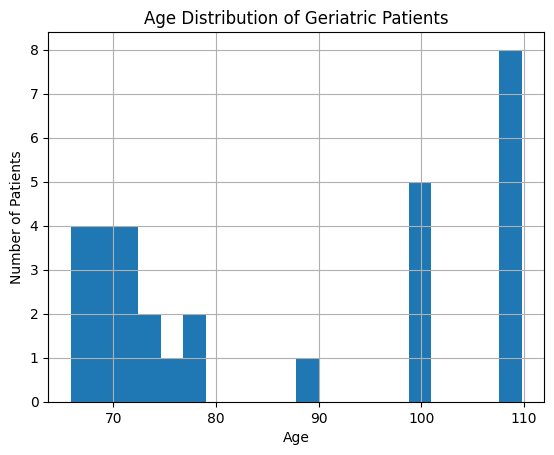

In [ ]:
#A) Age Distribution
OUTPUT_DIR = Path("../outputs/figures")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

plt.figure()
df["age"].hist(bins=20)
plt.xlabel("Age")
plt.ylabel("Number of Patients")
plt.title("Age Distribution of Geriatric Patients")
plt.savefig(OUTPUT_DIR / "age_distribution.png", bbox_inches="tight")
plt.show()

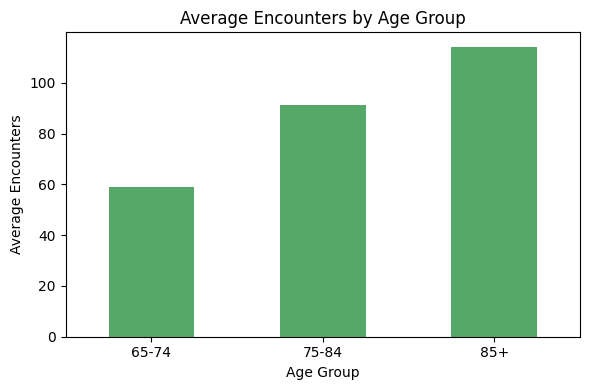

In [51]:
#B) Average Encounters by Age Group
encounters_by_age = df.groupby("age_group")["total_encounters"].mean()

plt.figure(figsize=(6,4))
encounters_by_age.plot(kind="bar", color="#55A868")
plt.ylabel("Average Encounters")
plt.xlabel("Age Group")
plt.title("Average Encounters by Age Group")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "encounters_by_age_group.png", bbox_inches="tight")
plt.show()


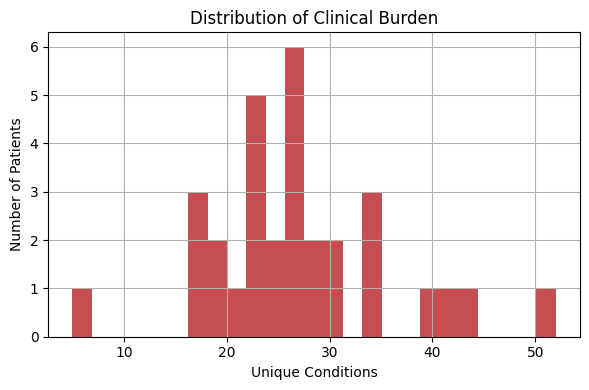

In [52]:
#C) Clinical Burden Distribution
plt.figure(figsize=(6,4))
df["unique_conditions"].hist(bins=25, color="#C44E52")
plt.xlabel("Unique Conditions")
plt.ylabel("Number of Patients")
plt.title("Distribution of Clinical Burden")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "clinical_burden_distribution.png", bbox_inches="tight")
plt.show()

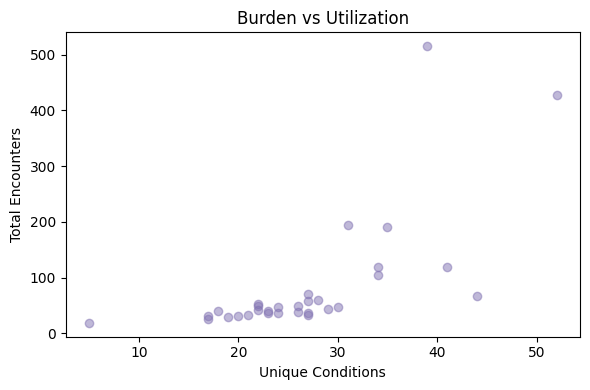

In [53]:
#D)Burden vs Utilization Scatter

plt.figure(figsize=(6,4))
plt.scatter(df["unique_conditions"], df["total_encounters"], alpha=0.5, color="#8172B2")
plt.xlabel("Unique Conditions")
plt.ylabel("Total Encounters")
plt.title("Burden vs Utilization")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "burden_vs_utilization.png", bbox_inches="tight")
plt.show()

These figures summarize patient complexity and utilization patterns across the geriatric cohort.  
They will be embedded in the project README to illustrate population structure and care‑gap insights.


The Notebook 2 produced: 
A. Insight tables / charts showing
age and demographics
utilization
burden
care gap proxy patterns

B. Preliminary conclusions

The next notebook will show segmentation